In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Numpy

In [2]:
a = np.array([1, 2, 3], dtype='f4', ndmin=3)

for i in (a, a.dtype, a.shape, a.ndim, a.flatten().base, a.ravel().base):
    print(i)

print(a.astype(complex))

[[[1. 2. 3.]]]
float32
(1, 1, 3)
3
None
[1. 2. 3.]
[[[1.+0.j 2.+0.j 3.+0.j]]]


In [3]:
b = a.copy()
c = a.view()

In [4]:
c[0, 0, 0] = 34

In [5]:
a, b, c

(array([[[34.,  2.,  3.]]], dtype=float32),
 array([[[1., 2., 3.]]], dtype=float32),
 array([[[34.,  2.,  3.]]], dtype=float32))

In [6]:
# The base of an array that owns its memory is None
# It is same as the original array whose view it is

# note `a.base is a` => False because a.base is simply [34., 2., 3.]
a.base, b.base, c.base, a.T.base, c.base is a.base

(array([34.,  2.,  3.], dtype=float32),
 None,
 array([34.,  2.,  3.], dtype=float32),
 array([34.,  2.,  3.], dtype=float32),
 True)

In [7]:
np.zeros((2, 3, 4), dtype='i4')

array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=int32)

In [8]:
np.empty((2, 3, 4), dtype='i4')

array([[[ 399215018,      21923,          0,          0],
        [ 264755376,      32758, 1613620976,      32758],
        [ 941386032,      32758,  263295728,      32758]],

       [[1638588080,      32758, 1547917488,      32758],
        [ 261878256,      32758,  261187632,      32758],
        [1639897712,      32758, 1639713008,      32758]]], dtype=int32)

In [9]:
np.identity(4, dtype='i4')

array([[1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]], dtype=int32)

In [10]:
np.eye(4, 3, -1)

array([[0., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [11]:
np.arange(10, 20, 2.5, dtype=float)

array([10. , 12.5, 15. , 17.5])

In [12]:
np.linspace(0, 9, 10)  # subtle
# step = (b - a) / (c - 1)

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [13]:
np.random.choice([10, 20, 30, 40, 50], size=(2, 3))

array([[40, 30, 30],
       [30, 20, 10]])

In [14]:
r = np.random.randint([1, 3, 5], [[10], [20], [6]], dtype=np.uint8)
r  # broadcasting!!!

array([[ 9,  6,  7],
       [17, 11,  6],
       [ 2,  3,  5]], dtype=uint8)

In [15]:
np.triu(r, k=1)

array([[0, 6, 7],
       [0, 0, 6],
       [0, 0, 0]], dtype=uint8)

In [16]:
a = np.arange(16).reshape(2,2,2,2)
# note how the base is different. and resize fills remaining elements
a, a.base, np.resize(a, (4,5))

(array([[[[ 0,  1],
          [ 2,  3]],
 
         [[ 4,  5],
          [ 6,  7]]],
 
 
        [[[ 8,  9],
          [10, 11]],
 
         [[12, 13],
          [14, 15]]]]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 array([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15,  0,  1,  2,  3]]))

In [17]:
a[:,:,:,0:1], a[:,:,:,0], a[...,0]  # note the difference in 1 and 2 and how 2 and 3 are the same
# when indexing, one dimension is flattened/lost
# when slicing, `ndims` preserved

# shapes: (2,2,2,1), (2,2,2), (2,2,2)

(array([[[[ 0],
          [ 2]],
 
         [[ 4],
          [ 6]]],
 
 
        [[[ 8],
          [10]],
 
         [[12],
          [14]]]]),
 array([[[ 0,  2],
         [ 4,  6]],
 
        [[ 8, 10],
         [12, 14]]]),
 array([[[ 0,  2],
         [ 4,  6]],
 
        [[ 8, 10],
         [12, 14]]]))

In [22]:
# Using np.ndenumerate to get index information while iterating
#np.ndenumerate() is a function that provides both the index and the value of each element
for idx, x in np.ndenumerate(a):
    print(f"Index {idx}: {x}")  # Prints the index and the corresponding value

Index (0, 0, 0, 0): 0
Index (0, 0, 0, 1): 1
Index (0, 0, 1, 0): 2
Index (0, 0, 1, 1): 3
Index (0, 1, 0, 0): 4
Index (0, 1, 0, 1): 5
Index (0, 1, 1, 0): 6
Index (0, 1, 1, 1): 7
Index (1, 0, 0, 0): 8
Index (1, 0, 0, 1): 9
Index (1, 0, 1, 0): 10
Index (1, 0, 1, 1): 11
Index (1, 1, 0, 0): 12
Index (1, 1, 0, 1): 13
Index (1, 1, 1, 0): 14
Index (1, 1, 1, 1): 15


In [18]:
# arr.reshape returns a view (can use -1 to infer)
# np.resize returns a new object (base exists and is not the same location in memory)
c = np.resize(a, (2, 4, 3))
c

array([[[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]],

       [[12, 13, 14],
        [15,  0,  1],
        [ 2,  3,  4],
        [ 5,  6,  7]]])

In [20]:
a.base, c.base   # note base of c is not just flattened out c, it is `a` concated enough times

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  0,
         1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]))

In [23]:
a.flatten(), a.flatten().base   # returns copy

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]), None)

In [24]:
c.ravel(), c.ravel().base   # returns view

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  0,
         1,  2,  3,  4,  5,  6,  7]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  0,
         1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]))

In [25]:
c, c.transpose(0, 2, 1), c.transpose(1, 0, 2), np.all(c.T==c.transpose(2, 1, 0))  # index (i,j,k) becomes (i,k,j) and (j,i,k) resp. (and k,j,i in last one)

(array([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],
 
        [[12, 13, 14],
         [15,  0,  1],
         [ 2,  3,  4],
         [ 5,  6,  7]]]),
 array([[[ 0,  3,  6,  9],
         [ 1,  4,  7, 10],
         [ 2,  5,  8, 11]],
 
        [[12, 15,  2,  5],
         [13,  0,  3,  6],
         [14,  1,  4,  7]]]),
 array([[[ 0,  1,  2],
         [12, 13, 14]],
 
        [[ 3,  4,  5],
         [15,  0,  1]],
 
        [[ 6,  7,  8],
         [ 2,  3,  4]],
 
        [[ 9, 10, 11],
         [ 5,  6,  7]]]),
 np.True_)

In [26]:
c.T.base

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  0,
        1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [27]:
d = np.expand_dims(c, axis=0)  # view
d, d.shape, np.squeeze(d), d.squeeze().shape  # view

(array([[[[ 0,  1,  2],
          [ 3,  4,  5],
          [ 6,  7,  8],
          [ 9, 10, 11]],
 
         [[12, 13, 14],
          [15,  0,  1],
          [ 2,  3,  4],
          [ 5,  6,  7]]]]),
 (1, 2, 4, 3),
 array([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],
 
        [[12, 13, 14],
         [15,  0,  1],
         [ 2,  3,  4],
         [ 5,  6,  7]]]),
 (2, 4, 3))

In [28]:
e = np.squeeze(d)
e[0, 0, 0] = 24
e, d, c

(array([[[24,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],
 
        [[12, 13, 14],
         [15,  0,  1],
         [ 2,  3,  4],
         [ 5,  6,  7]]]),
 array([[[[24,  1,  2],
          [ 3,  4,  5],
          [ 6,  7,  8],
          [ 9, 10, 11]],
 
         [[12, 13, 14],
          [15,  0,  1],
          [ 2,  3,  4],
          [ 5,  6,  7]]]]),
 array([[[24,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],
 
        [[12, 13, 14],
         [15,  0,  1],
         [ 2,  3,  4],
         [ 5,  6,  7]]]))

### Broadcasting
When operating on two arrays, NumPy compares their shapes element-wise. It starts with the trailing (i.e. rightmost) dimension and works its way left. Two dimensions are compatible when

- they are equal, or
- one of them is 1.


In [43]:
?np.split

Signature:       np.split(ary, indices_or_sections, axis=0)
Call signature:  np.split(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function split at 0x7fc1c85fb490>
File:            ~/.local/lib/python3.10/site-packages/numpy/lib/_shape_base_impl.py
Docstring:      
Split an array into multiple sub-arrays as views into `ary`.

Parameters
----------
ary : ndarray
    Array to be divided into sub-arrays.
indices_or_sections : int or 1-D array
    If `indices_or_sections` is an integer, N, the array will be divided
    into N equal arrays along `axis`.  If such a split is not possible,
    an error is raised.

    If `indices_or_sections` is a 1-D array of sorted integers, the entries
    indicate where along `axis` the array is split.  For example,
    ``[2, 3]`` would, for ``axis=0``, result in

    - ary[:2]
    - ary[2:3]
    - ary[3:]

    If an index exceeds the dimension of the array along `axis`,
    an empty sub-array is returned correspondingly.
a

In [27]:
x = np.arange(8)
y = x * (2 ** x.reshape(8, 1))
y

array([[  0,   1,   2,   3,   4,   5,   6,   7],
       [  0,   2,   4,   6,   8,  10,  12,  14],
       [  0,   4,   8,  12,  16,  20,  24,  28],
       [  0,   8,  16,  24,  32,  40,  48,  56],
       [  0,  16,  32,  48,  64,  80,  96, 112],
       [  0,  32,  64,  96, 128, 160, 192, 224],
       [  0,  64, 128, 192, 256, 320, 384, 448],
       [  0, 128, 256, 384, 512, 640, 768, 896]])

In [28]:
np.split(y, 4)

[array([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 0,  2,  4,  6,  8, 10, 12, 14]]),
 array([[ 0,  4,  8, 12, 16, 20, 24, 28],
        [ 0,  8, 16, 24, 32, 40, 48, 56]]),
 array([[  0,  16,  32,  48,  64,  80,  96, 112],
        [  0,  32,  64,  96, 128, 160, 192, 224]]),
 array([[  0,  64, 128, 192, 256, 320, 384, 448],
        [  0, 128, 256, 384, 512, 640, 768, 896]])]

In [29]:
np.split(y, 4, axis=1)

[array([[  0,   1],
        [  0,   2],
        [  0,   4],
        [  0,   8],
        [  0,  16],
        [  0,  32],
        [  0,  64],
        [  0, 128]]),
 array([[  2,   3],
        [  4,   6],
        [  8,  12],
        [ 16,  24],
        [ 32,  48],
        [ 64,  96],
        [128, 192],
        [256, 384]]),
 array([[  4,   5],
        [  8,  10],
        [ 16,  20],
        [ 32,  40],
        [ 64,  80],
        [128, 160],
        [256, 320],
        [512, 640]]),
 array([[  6,   7],
        [ 12,  14],
        [ 24,  28],
        [ 48,  56],
        [ 96, 112],
        [192, 224],
        [384, 448],
        [768, 896]])]

In [30]:
np.split(y, [2, 3, 7], axis=0)

[array([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 0,  2,  4,  6,  8, 10, 12, 14]]),
 array([[ 0,  4,  8, 12, 16, 20, 24, 28]]),
 array([[  0,   8,  16,  24,  32,  40,  48,  56],
        [  0,  16,  32,  48,  64,  80,  96, 112],
        [  0,  32,  64,  96, 128, 160, 192, 224],
        [  0,  64, 128, 192, 256, 320, 384, 448]]),
 array([[  0, 128, 256, 384, 512, 640, 768, 896]])]

In [32]:
np.array_split(x, 3)

[array([0, 1, 2]), array([3, 4, 5]), array([6, 7])]

In [40]:
np.where(x % 2 == 0, x, -x)

array([ 0, -1,  2, -3,  4, -5,  6, -7])

In [41]:
?np.sort

Signature:       np.sort(a, axis=-1, kind=None, order=None, *, stable=None)
Call signature:  np.sort(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function sort at 0x7f74781e1750>
File:            ~/.local/lib/python3.10/site-packages/numpy/_core/fromnumeric.py
Docstring:      
Return a sorted copy of an array.

Parameters
----------
a : array_like
    Array to be sorted.
axis : int or None, optional
    Axis along which to sort. If None, the array is flattened before
    sorting. The default is -1, which sorts along the last axis.
kind : {'quicksort', 'mergesort', 'heapsort', 'stable'}, optional
    Sorting algorithm. The default is 'quicksort'. Note that both 'stable'
    and 'mergesort' use timsort or radix sort under the covers and,
    in general, the actual implementation will vary with data type.
    The 'mergesort' option is retained for backwards compatibility.

    .. versionchanged:: 1.15.0.
       The 'stable' option was added.

order : str or

In [31]:
!python3 06-func.py

1. Concatenate 1D arrays
 [1 2 3 4 5 6]

2. Concatenate 2D arrays along axis 0
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
Shape is (4, 2)

3. Concatenate 2D arrays along axis 1
 [[1 2 5 6]
 [3 4 7 8]]
Shape is (2, 4)

4. Stacking along axis=0
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
Shape is (2, 2, 2)

5. Stacking along axis=1
[[[1 2]
  [5 6]]

 [[3 4]
  [7 8]]]
Shape is (2, 2, 2)

6. Splitting 1D array
Split 1D array into 3 parts: [array([1, 2]), array([3, 4]), array([5, 6])]
Accessing first array: [1 2]
7. Array split into 4 parts (uneven split): [1 2]
7. Array split into 4 parts (uneven split): [3 4]
7. Array split into 4 parts (uneven split): [5]
7. Array split into 4 parts (uneven split): [6]

8. Splitting 2D array along axis 1
First split result: [[ 1]
 [ 4]
 [ 7]
 [10]
 [13]
 [16]]

9. Searching array for element 4:
Index positions where element is 4: (array([3, 5, 6]),)

10. Searching for odd values:
Index positions where values are odd: (array([0, 2, 4]),)

11. Sorting 2D array
Sorted array: [[

## MPL

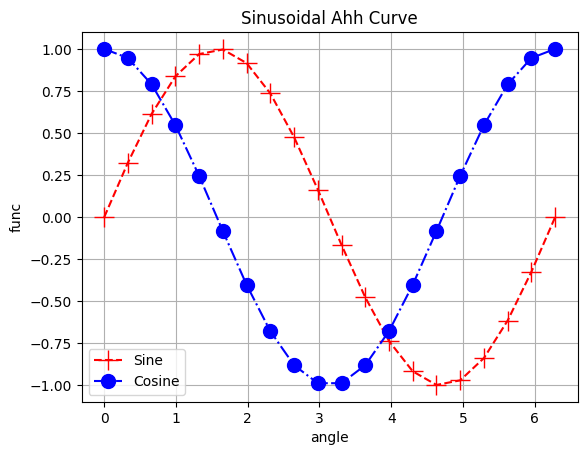

haha


In [40]:
x = np.linspace(0, 2*np.pi, 20)
y = np.sin(x)

plt.plot(x, y, ls='--', c='red', marker='+', ms='15', label='Sine')
plt.plot(x, np.cos(x), 'bo-.', ms='10', label='Cosine')
plt.grid(True)
plt.title("Sinusoidal Ahh Curve")
plt.legend()

plt.xlabel("angle")
plt.ylabel("func")
plt.show()
print('haha')

In [43]:
?plt.grid

Signature:
plt.grid(
    visible: 'bool | None' = None,
    which: "Literal['major', 'minor', 'both']" = 'major',
    axis: "Literal['both', 'x', 'y']" = 'both',
    **kwargs,
) -> 'None'
Docstring:
Configure the grid lines.

Parameters
----------
visible : bool or None, optional
    Whether to show the grid lines.  If any *kwargs* are supplied, it
    is assumed you want the grid on and *visible* will be set to True.

    If *visible* is *None* and there are no *kwargs*, this toggles the
    visibility of the lines.

which : {'major', 'minor', 'both'}, optional
    The grid lines to apply the changes on.

axis : {'both', 'x', 'y'}, optional
    The axis to apply the changes on.

**kwargs : `~matplotlib.lines.Line2D` properties
    Define the line properties of the grid, e.g.::

        grid(color='r', linestyle='-', linewidth=2)

    Valid keyword arguments are:

    Properties:
    agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n

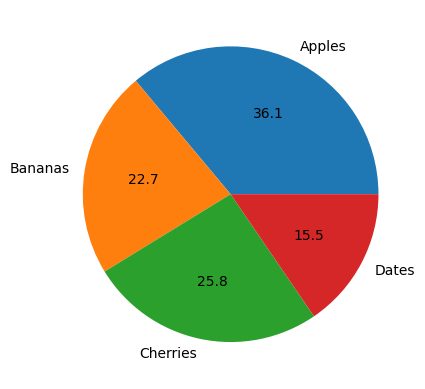

In [ ]:
y = np.array([35, 21, 25, 15])
mylabels = ["Apples", "Bananas", "Cherries", "Dates"]  # Labels for the pie chart sections
plt.pie(y, labels=mylabels, autopct=lambda x: f"{x:.1f}")  # Plotting the pie chart with labels
plt.show()  # Show the plot

In [34]:
a = np.array([[0, 1],
			  [2, 3]])
b = np.array([2, 3])
np.dot(a, b)

array([ 3, 13])

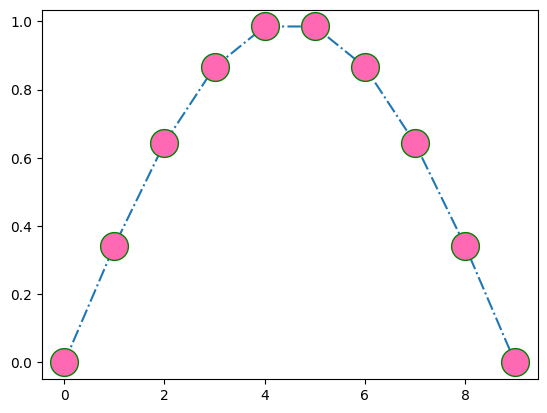

In [38]:
# 3. Customizing Markers (Size, Edge Color, Line Style, Face Color)
#Notice I am not using xpoints. It will plot ypoints assuming xpoints [0,1,2,3]
plt.plot(np.sin(np.linspace(0, np.pi, 10)), marker='o', ms=20, mec='g', ls='-.', mfc='hotpink')

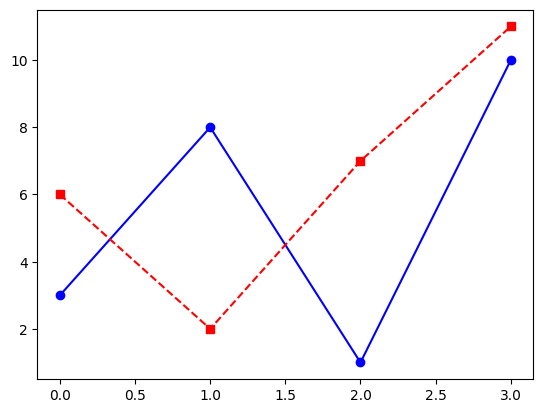

In [40]:
x1 = np.array([0, 1, 2, 3])
y1 = np.array([3, 8, 1, 10])
x2 = np.array([0, 1, 2, 3])
y2 = np.array([6, 2, 7, 11])

# multiple on same plot

#plt.plot(x1, y1, 'bo-')  # Blue circles with solid line
#plt.plot(x2, y2, 'rs--')  # Red squares with dashed line
plt.plot(x1, y1, 'bo-', x2, y2, 'rs--')

In [41]:
?plt.plot

Signature:
plt.plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs,
) -> 'list[Line2D]'
Docstring:
Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yie

/tmp/ipykernel_32942/392359938.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')  # Show legend


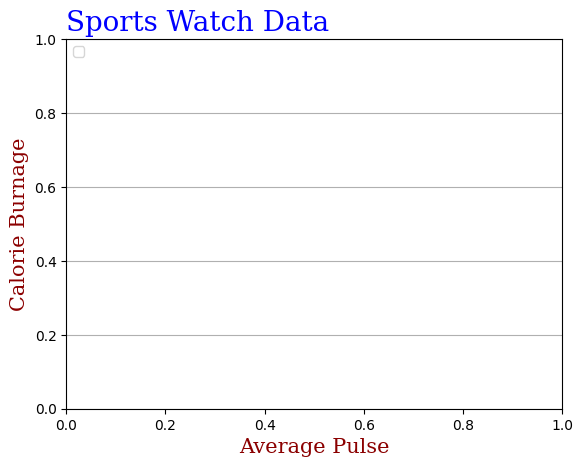

In [43]:
font1 = {'family': 'serif', 'color': 'blue', 'size': 20}
font2 = {'family': 'serif', 'color': 'darkred', 'size': 15}

# Plot the first graph (Sports Watch Data)
plt.title("Sports Watch Data", fontdict=font1, loc='left')
plt.xlabel("Average Pulse", fontdict=font2)
plt.ylabel("Calorie Burnage", fontdict=font2)
plt.grid(axis='y')
plt.legend(loc='upper left')  # Show legend
None

In [44]:
?plt.legend

Signature: plt.legend(*args, **kwargs) -> 'Legend'
Docstring:
Place a legend on the Axes.

Call signatures::

    legend()
    legend(handles, labels)
    legend(handles=handles)
    legend(labels)

The call signatures correspond to the following different ways to use
this method:

**1. Automatic detection of elements to be shown in the legend**

The elements to be added to the legend are automatically determined,
when you do not pass in any extra arguments.

In this case, the labels are taken from the artist. You can specify
them either at artist creation or by calling the
:meth:`~.Artist.set_label` method on the artist::

    ax.plot([1, 2, 3], label='Inline label')
    ax.legend()

or::

    line, = ax.plot([1, 2, 3])
    line.set_label('Label via method')
    ax.legend()

.. note::
    Specific artists can be excluded from the automatic legend element
    selection by using a label starting with an underscore, "_".
    A string starting with an underscore is the default label for a

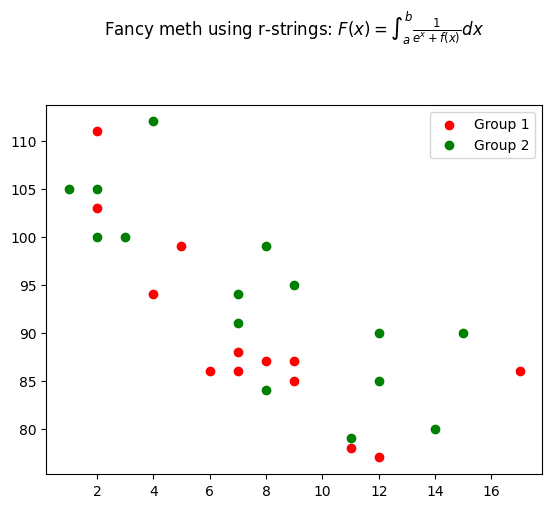

In [70]:
# Scatter Plot 1
x = np.array([5, 7, 8, 7, 2, 17, 2, 9, 4, 11, 12, 9, 6])
y = np.array([99, 86, 87, 88, 111, 86, 103, 87, 94, 78, 77, 85, 86])
plt.scatter(x, y, color='red', label="Group 1")  # Scatter plot with red color for Group 1

# Scatter Plot 2
x = np.array([2, 2, 8, 1, 15, 8, 12, 9, 7, 3, 11, 4, 7, 14, 12])
y = np.array([100, 105, 84, 105, 90, 99, 90, 95, 94, 100, 79, 112, 91, 80, 85])
plt.scatter(x, y, color='green', label="Group 2")  # Scatter plot with green color for Group 2
plt.legend()  # Display the legend
plt.title(r'Fancy meth using r-strings: $F(x) = \int_{a}^{b} \frac{1}{e^x + f(x)} dx$', pad = 50)
plt.show()  # Show the plot

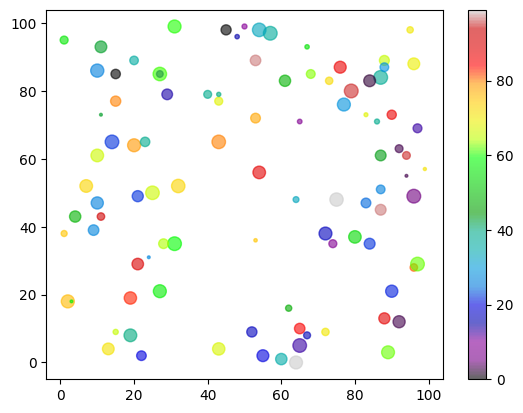

In [46]:
# Scatter plot with random data
# size is 100 random integers; first argument says between 0 and 99 for x-axis
x = np.random.randint(100, size=(100))  
y = np.random.randint(100, size=(100))
# Colors for each point, chosen randomly
colors = np.random.randint(100, size=(100))  # This assigns a unique color value to each point
# Sizes of the points, chosen randomly
sizes = np.random.randint(100, size=(100))  # This controls the size of each point in the scatter plot (larger = bigger points)

# Scatter plot with various customizations
plt.scatter(x, y, 
            c=colors,        # Color each point according to the value in 'colors' array
            s=sizes,         # Size each point according to the value in 'sizes' array
            alpha=0.6,       # Transparency of the points; 0 is fully transparent, 1 is fully opaque
            cmap='nipy_spectral')  # Color map to map 'colors' to specific colors; 'nipy_spectral' is a built-in colormap
            # 'cmap' defines which color scheme to apply to the data. 'nipy_spectral' is a color map, 
            # but you can experiment with 'viridis', 'plasma', 'inferno', etc., for different visual effects.

# Display the color scale (colorbar)
plt.colorbar()  # Shows a colorbar that reflects the colormap range and how the data values correspond to colors
plt.show()  # Show the plot


Given array $A$ compute $\sum_{i<j} 2 a_i - a_j$. TRying without `np.triu`

In [65]:
a = np.array([0, 1, 2])

b = 2 * a[None, :] - a[:, None]
print(b)

# Method 1: mask from indices
rows, cols = np.indices(b.shape)
mask = rows < cols
print(mask)

print(np.sum(b[mask]**2, axis=None))
print('='*80)

# Method 2: indexing using where(row_indices < col_indices)
c = np.where(np.arange(b.shape[0])[:, None] < np.arange(b.shape[1])[None, :], b, 0)
print(c)

print(np.sum(c**2, None))

[[ 0  2  4]
 [-1  1  3]
 [-2  0  2]]
[[False  True  True]
 [False False  True]
 [False False False]]
29
[[0 2 4]
 [0 0 3]
 [0 0 0]]
29


Common funcs
```python
matplotlib.pyplot.bar(x, height, width=0.8, bottom=None, *, align='center', data=None, **kwargs)

matplotlib.pyplot.hist(x, bins=None, range=None, density=False, weights=None, cumulative=False, **kwargs)

matplotlib.pyplot.subplot(nrows, ncols, index, **kwargs)

matplotlib.pyplot.savefig(fname, dpi=None, facecolor='w', edgecolor='w', orientation='portrait', format=None, transparent=False, bbox_inches=None, pad_inches=0.1, **kwargs)

# bbox_inches='tight'
```

#### Given positions `r (n,2)` and masses `m (n,)` find total gravitational force vectors on each point mass.

In [138]:
# r => (n,2)
# m => (n,)

G = 1

r = np.array([[0, 0],
			  [1, 2],
			  [1, 2]])
m = np.array([1, 2, 3])

m_ij = m[:, None] * m[None, :]         # m_i * m_j
r_ij = r[:, None, :] - r[None, :, :]   # r_i - r_j
d_ij = np.linalg.norm(r_ij, axis=2)    # norm along axis=2

# broadcast m_ij and d_ij along 3rd dim (clip to deal w zeros)
F_ij = (G * m_ij[:, :, None] * (-r_ij)) / np.clip(d_ij[:, :, None], 1e-10, np.inf) ** 3

# sum along 2nd dim to get total forces on points (which are along 1st dim)
F_i = np.sum(F_ij, axis=1)

print(F_i)

[[ 0.4472136   0.89442719]
 [-0.17888544 -0.35777088]
 [-0.26832816 -0.53665631]]


In [101]:
m_ij

array([[1, 2],
       [2, 4]])

In [108]:
r_ij[:,:,0], r_ij[:,:,1], r_ij

(array([[ 0, -1],
        [ 1,  0]]),
 array([[ 0, -2],
        [ 2,  0]]),
 array([[[ 0,  0],
         [-1, -2]],
 
        [[ 1,  2],
         [ 0,  0]]]))

In [103]:
np.clip(np.linalg.norm(r_ij, axis=2), 1e-10, np.inf)

array([[1.00000000e-10, 2.23606798e+00],
       [2.23606798e+00, 1.00000000e-10]])

In [115]:
(G * m_ij[:,:,None] * (-r_ij))[:,:,0], (G * m_ij[:,:,None] * (-r_ij))[:,:,1]

(array([[ 0,  2],
        [-2,  0]]),
 array([[ 0,  4],
        [-4,  0]]))

In [124]:
(G * m_ij[:,:,None] * (-r_ij)) / np.clip(np.linalg.norm(r_ij, axis=2)[:, :, None], 1e-10, np.inf) ** (3)

array([[[ 0.        ,  0.        ],
        [ 0.17888544,  0.35777088]],

       [[-0.17888544, -0.35777088],
        [ 0.        ,  0.        ]]])

In [125]:
np.sum((G * m_ij[:,:,None] * (-r_ij)) / np.clip(np.linalg.norm(r_ij, axis=2)[:, :, None], 1e-10, np.inf) ** (3), axis=1)

array([[ 0.17888544,  0.35777088],
       [-0.17888544, -0.35777088]])

In [129]:
(2 / np.sqrt(5) ** (3)) * np.array([1, 2])

array([0.17888544, 0.35777088])